In [ ]:
# import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
! pip install nnfs

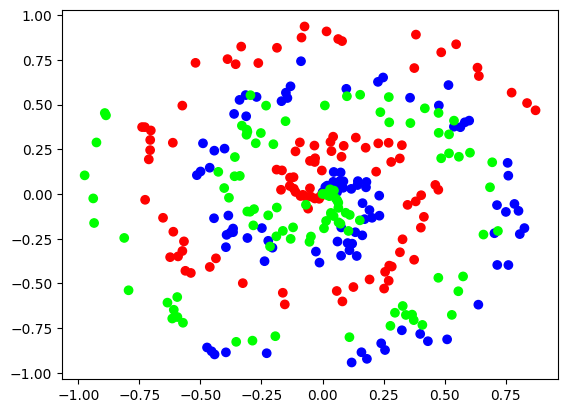

In [ ]:
from nnfs.datasets import spiral_data   # import the dataset
X ,y = spiral_data(100,3)  # 100 datapoints (coordinates) , each one with a class associated to it
plt.scatter(X[:,0],X[:,1],c=y,cmap='brg') # the first col = X coord , second col = y coord , var y has the class label

In [ ]:
# class implementing the dense layers
class DenseLayer:
  def __init__(self,n_inputs,n_neurons,lambda_l1 , lambda_l2) -> None:
    self.weights = 0.1 * np.random.randn(n_inputs,n_neurons)  # initialize and store weight matrix with small random numbers
    self.bias = np.zeros((1,n_neurons)) # initalize and store bias matrix with zeros
    self.lambda_l1 = lambda_l1
    self.lambda_l2 = lambda_l2

  def forward(self,X):
    self.inputs = X     # store the input
    self.output = self.inputs@self.weights + self.bias  # weighted sum (Z)
    return self.output  # return the weighted sum

  # for any layer's backward pass , the dvalues is the gradient of the loss wrt the same layer's output

  def backward(self,dvalues): # input is dloss_dz
    self.dweights = self.inputs.T @ dvalues           # dloss_dw

    if self.lambda_l2 :
      self.dweights+=2*self.lambda_l2*self.weights    # add the penalty term of weights**2 for l2

    if self.lambda_l1:
      dL1 = np.ones_like(self.weights)
      dL1[self.weights<0]=-1

      self.dweights += self.lambda_l1*dL1            # add the penalty term of mod(weights) for l1

    self.dbias = np.sum(dvalues,axis=0,keepdims=True) # dloss_db
    self.dinputs = dvalues@self.weights.T             # dloss_dX

  # and for any layer's backward pass, the output is the dvalues for the previous layers behind it

In [ ]:
# class implementing Relu activation
class ReLU:
  def forward(self,inputs): # inputs = weighted sum
    self.inputs = inputs    # store the inputs
    self.output = np.maximum(0,self.inputs)   # relu formula

  def backward(self,dvalues): # input = dloss_drelu-output
    relu_derivative =  np.where(self.inputs>0,1,0)    # relu derivative
    self.dinputs = dvalues * relu_derivative        # apply the relu derivative to the weight matrix
    return self.dinputs     # return the dloss_dz


In [ ]:
# class implementing Softmax and Categorical cross entropy

class SoftmaxCrossEntropy:
  def SoftMax_forward(self,weighted_sum):   # this makes the predictions : e^z1 / e^z1 + e^z2 + e^z3
    shifted = weighted_sum - np.max(weighted_sum ,axis =1 , keepdims = True) # subtract the maximum of each row from each number
    exp_weighted_sum = np.exp(shifted) # get exponents of each value
    self.output =  exp_weighted_sum / np.sum(exp_weighted_sum,axis=1,keepdims=True)
    return self.output

  def CC_forward(self,softmax_output,true_labels):    # this gets the loss : categorical cross entropy -> - summation yilog(yi_hat)
    samples,classes = softmax_output.shape      # convert the true_labels into one hot encoding if not given
    if len(true_labels.shape)==1:
      true_labels = np.eye(classes)[true_labels]
    clipped = np.clip(softmax_output,1e-7,1-1e-7) # clip to prevent log(0)
    corrected_confidence = np.sum(clipped*true_labels,axis=1) # sigma yi_hat
    negative_log_likelihood = -np.log(corrected_confidence) # -yi log yi_hat
    return np.mean(negative_log_likelihood) # return avg loss

  def backward(self,y_true,y_pred):
    # partial differentiation of the loss wrt the weights (DL_Dz) is given by y_True-y_pred when softmax and CCE are used together
    samples  = y_pred.shape[0]
    classes = y_pred.shape[1]
    if len(y_true.shape) == 1 : # ohe the true matrix , if not
      y_true = np.eye(classes)[y_true]
    Dloss_Dz = y_pred - y_true    # dloss_dz is the difference of the pred and true
    Dloss_Dz /= samples  # divide by number of samples to normalize
    return Dloss_Dz


In [ ]:
class Dropout:
  def __init__(self,droput_rate) -> None:
    self.keep_prob = 1-droput_rate

  def forward(self, inputs, training=True):
    self.inputs = inputs

    if not training:
        self.output = inputs
        return

    self.mask = np.random.binomial(1, self.keep_prob, size=inputs.shape) / self.keep_prob
    self.output = inputs * self.mask

  def backward(self,dvalues):
    self.dinputs = dvalues*self.mask

In [ ]:
# implementing the optimizers : Batch gradient descent , learning rate decay , momentum

class gd_decay_momentum_optimizer:
  def __init__(self,learning_rate=1.0,decay =0.0,momentum = 0.0):
    self.initial_lr = learning_rate
    self.lr = learning_rate
    self.decay = decay
    self.momentum = momentum
    self.t = 0

  def update_lr(self):  # get the decaying learning rate from the initial learning rate for the current time t
    if self.decay : # implement the decaying lr only if the decay parameter is given
      self.lr = self.initial_lr/(1+self.decay*self.t)
    self.t+=1

  def update_parameters(self,layer):
    # if we use momentum
    if self.momentum:
      # wt = wt-1 - self.decay*(layer.dweights) + (self.momentum * velocity)     velocity = previous weight updates
      if not hasattr(layer,'weight_momentum'):
        # for each layer , before the first update there are no previous weight updates , hence the weight and bias momentum initially is a matrix of 0s
        layer.weight_momentum = np.zeros_like(layer.weights)
        layer.bias_momentum = np.zeros_like(layer.bias)

      # updating
      weight_update = self.momentum * layer.weight_momentum - self.lr*layer.dweights
      layer.weight_momentum = weight_update

      bias_update = self.momentum*layer.bias_momentum - self.lr*layer.dbias
      layer.bias_momentum = bias_update

    else:
      # use the vanilla gradient descent's update rule
      weight_update = -self.lr*layer.dweights
      bias_update = -self.lr*layer.dbias

    # update
    layer.weights+=weight_update
    layer.bias += bias_update

In [ ]:
# adagrad class

# The performance of adagrad is not that great as the update in the weight stops or happens by a very very small value after a point
# this happens due to the increased value of cache in the denominator , due to which the update paramter never changes
# and hence the original parameters never change

class adagrad_optimizer:
  def __init__(self,learning_rate=1.0,decay=0.0,epsilon=1e-7) -> None:
    self.initial_lr = learning_rate
    self.lr = learning_rate
    self.decay = decay
    self.iterations = 0
    self.epsilon= epsilon   # constant term to avoid division by 0

  def pre_update(self):
    # decaying lr
    if self.decay:
      self.lr = self.initial_lr/(1+self.decay*self.iterations)

  def update_parameters(self,layer):
    # intialize the cache to store the update history of parameters
    if not hasattr(layer,'weight_cache'):
      layer.weight_cache = np.zeros_like(layer.weights)
      layer.bias_cache = np.zeros_like(layer.bias)

    layer.weight_cache += (layer.dweights)**2   # add the square of the current gradients in the cache
    layer.bias_cache += (layer.dbias)**2

    # update parameters
    weight_update = -self.lr * layer.dweights/np.sqrt(layer.weight_cache+self.epsilon)
    bias_update = -self.lr*layer.dbias / np.sqrt(layer.bias_cache+self.epsilon)


    # update
    layer.weights+=weight_update
    layer.bias += bias_update

  def post_update(self):
    # increment the iteration
    self.iterations+=1

In [ ]:
# rmsprop optimizer
class rmsprop_optimizer:
  def __init__(self,learning_rate=0.001,decay=0.0,epsilon=1e-7,rho=0.9) -> None:
    self.initial_lr = learning_rate
    self.lr = learning_rate
    self.decay = decay
    self.iterations = 0
    self.epsilon= epsilon   # constant term to avoid division by 0
    self.rho = rho          # hyperparameter in the cache equation of rms prop

  def pre_update(self):
    # decaying lr
    if self.decay:
      self.lr = self.initial_lr/(1+self.decay*self.iterations)

  def update_parameters(self,layer):
    # intialize the cache to store the update history of parameters
    if not hasattr(layer,'weight_cache'):
      layer.weight_cache = np.zeros_like(layer.weights)
      layer.bias_cache = np.zeros_like(layer.bias)

    layer.weight_cache = self.rho*layer.weight_cache + (1-self.rho)*(layer.dweights)**2
    layer.bias_cache = self.rho*layer.bias_cache + (1-self.rho)*(layer.dbias)**2

    # update parameters
    weight_update = -self.lr * layer.dweights/np.sqrt(layer.weight_cache+self.epsilon)
    bias_update = -self.lr*layer.dbias / np.sqrt(layer.bias_cache+self.epsilon)

    # update
    layer.weights+=weight_update
    layer.bias += bias_update

  def post_update(self):
    # increment the iteration
    self.iterations+=1


In [ ]:
class AdamOptimizer:
    def __init__(self, learning_rate=0.001, decay=0.0, epsilon=1e-7, b1=0.9, b2=0.999):
        self.learning_rate = learning_rate
        self.lr = learning_rate
        self.initial_lr = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.beta1 = b1
        self.beta2 = b2

    def pre_update(self):
        if self.decay:
            self.lr = self.initial_lr / (1 + self.decay * self.iterations)

    def update_parameters(self, layer):

        # Initialize
        if not hasattr(layer, 'weight_cache'):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.bias)

            layer.weight_momentum = np.zeros_like(layer.weights)
            layer.bias_momentum = np.zeros_like(layer.bias)

        # Update momentum
        layer.weight_momentum = (self.beta1 * layer.weight_momentum +(1 - self.beta1) * layer.dweights)

        layer.bias_momentum = (self.beta1 * layer.bias_momentum +(1 - self.beta1) * layer.dbias)

        # Update cache
        layer.weight_cache = (self.beta2 * layer.weight_cache +(1 - self.beta2) * (layer.dweights ** 2))

        layer.bias_cache = (self.beta2 * layer.bias_cache +(1 - self.beta2) * (layer.dbias ** 2))

        # update parameters
        t = self.iterations + 1


        m_hat_w = layer.weight_momentum / (1 - self.beta1 ** t)
        m_hat_b = layer.bias_momentum / (1 - self.beta1 ** t)

        v_hat_w = layer.weight_cache / (1 - self.beta2 ** t)
        v_hat_b = layer.bias_cache / (1 - self.beta2 ** t)

        # update
        layer.weights -= self.lr * (m_hat_w / (np.sqrt(v_hat_w) + self.epsilon))
        layer.bias -= self.lr * (m_hat_b / (np.sqrt(v_hat_b) + self.epsilon))

    def post_update(self):
        self.iterations += 1

In [ ]:
# creating the model
dense1 = DenseLayer(2,64,lambda_l1=0.0,lambda_l2=1e-4)
dense2 = DenseLayer(64,3,lambda_l1=0.0,lambda_l2=1e-4)
relu = ReLU()
sce = SoftmaxCrossEntropy()
dropout = Dropout(0.1)
#opt = Optimizer(decay=1e-3,momentum=0.9)                          # momentum
#opt = adagrad_optimizer(decay=1e-4)                               # adagrad
#opt = rmsprop_optimizer(learning_rate=0.001,decay=1e-5,rho=0.9)   # rmsprop
opt = AdamOptimizer(learning_rate=0.001,decay=1e-5)                 # adam
for i in range(10001):
  # forward pass
  dense1.forward(X)
  relu.forward(dense1.output)
  dropout.forward(relu.output)
  dense2.forward(dropout.output)
  y_pred = sce.SoftMax_forward(dense2.output)

  loss = sce.CC_forward(y_pred,y)

  if dense1.lambda_l2 :
    loss+=dense1.lambda_l2*np.sum(dense1.weights**2)

  if dense2.lambda_l2:
    loss+=dense2.lambda_l2*np.sum(dense2.weights**2)

  if dense1.lambda_l1:
    loss+=dense1.lambda_l1*np.sum(np.abs(dense1.weights))

  if dense2.lambda_l1:
    loss+=dense2.lambda_l1*np.sum(np.abs(dense2.weights))


  # backward pass
  dloss_dz2 = sce.backward(y,y_pred) # derivative of the loss wrt z2 (z2 is the input to 2nd dense layer) , so this calcultes DLoss
  dense2.backward(dloss_dz2)
  dropout.backward(dense2.dinputs)
  relu.backward(dropout.dinputs)
  dense1.backward(relu.dinputs)

  # vanilla gd for updating
  #gd.update_parameters(dense1)
  #gd.update_parameters(dense2)

  opt.pre_update() # using decaying learning rate
  opt.update_parameters(dense1)
  opt.update_parameters(dense2)
  opt.post_update()

  if i % 100 == 0:
    predictions = np.argmax(y_pred, axis=1)
    acc = np.mean(predictions == y)
    print(f"epoch : {i},Loss: {loss:.4f}, Acc: {acc:.4f} , lr : {opt.lr}")




epoch : 0,Loss: 1.0957, Acc: 0.3833 , lr : 0.001
epoch : 100,Loss: 1.0583, Acc: 0.4400 , lr : 0.0009990009990009992
epoch : 200,Loss: 1.0539, Acc: 0.4500 , lr : 0.000998003992015968
epoch : 300,Loss: 1.0484, Acc: 0.4567 , lr : 0.0009970089730807579
epoch : 400,Loss: 1.0396, Acc: 0.4667 , lr : 0.00099601593625498
epoch : 500,Loss: 1.0275, Acc: 0.4667 , lr : 0.0009950248756218907
epoch : 600,Loss: 1.0184, Acc: 0.4633 , lr : 0.0009940357852882705
epoch : 700,Loss: 1.0045, Acc: 0.4767 , lr : 0.00099304865938431
epoch : 800,Loss: 1.0030, Acc: 0.5133 , lr : 0.000992063492063492
epoch : 900,Loss: 0.9854, Acc: 0.5233 , lr : 0.000991080277502478
epoch : 1000,Loss: 0.9947, Acc: 0.5133 , lr : 0.0009900990099009901
epoch : 1100,Loss: 0.9763, Acc: 0.5000 , lr : 0.0009891196834817015
epoch : 1200,Loss: 0.9748, Acc: 0.4933 , lr : 0.0009881422924901185
epoch : 1300,Loss: 0.9569, Acc: 0.4967 , lr : 0.000987166831194472
epoch : 1400,Loss: 0.9464, Acc: 0.5000 , lr : 0.0009861932938856016
epoch : 1500,Los

In [ ]:
# creating another dataset for testing
# on this dataset no backward pass will be done , we will load the learnt weights and make preditions directly

from nnfs.datasets import spiral_data
X_test,y_test = spiral_data(1000,3)  # make the testing data

dense1.forward(X_test)
relu.forward(dense1.output)

# DO NOT use dropout during testing
dense2.forward(relu.output)

y_pred = sce.SoftMax_forward(dense2.output)

loss = sce.CC_forward(y_pred, y_test)

predictions = np.argmax(y_pred, axis=1)

if len(y_test.shape) == 2:
    y_test = np.argmax(y_test, axis=1)

accuracy = np.mean(predictions == y_test)

print(f'validation, acc:{accuracy:.3f}, loss:{loss:.3f}')

validation, acc:0.624, loss:0.898


In [ ]:
# using the l2 , the training accuracy is reduced as bias increases
# and the validation accuracy increases as variance is reduced

In [ ]:
# using the dropouts the training accuracy significantly drops , as the bias increses , but the validation accuracy increases